In [55]:
import re
import torch
import torch.nn as nn
import torch.optim as optim

# Simple embedding example
# -------------------------

# Example texts
texts = [
    "i am not done",
    "it is not over",
    "i will not quit",
    "i keep going",
    "i keep trying",
    "i move forward",
    "i stay strong",
    "i believe in myself",
    "i will win",
]

# Vocabulary
# -------------------------
class Vocabulary:
    def __init__(self):
        self.token_to_idx = {"<PAD>":0, "<UNK>":1, "<BOS>":2, "<EOS>":3}
        self.idx_to_token = {i:t for t,i in self.token_to_idx.items()}
        self.next_idx = 4

    def add_token(self, token):
        if token not in self.token_to_idx:
            self.token_to_idx[token] = self.next_idx
            self.idx_to_token[self.next_idx] = token
            self.next_idx += 1

    def build(self, texts):
        for text in texts:
            tokens = re.findall(r"\w+|[^\w\s]", text.lower())
            for token in tokens:
                self.add_token(token)

    def encode(self, text):
        tokens = re.findall(r"\w+|[^\w\s]", text.lower())
        return [self.token_to_idx.get(t, 1) for t in tokens]

    def decode(self, indices):
        return [self.idx_to_token.get(i, "<UNK>") for i in indices]

    def __len__(self):
        return len(self.token_to_idx)


# Mini model
# -------------------------
class SimpleModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, x):
        # x: [seq_len]
        embeds = self.embedding(x)        # [seq_len, embed_dim]
        vector = embeds.mean(dim=0)      # simple average pooling
        out = self.fc(vector)            # [output_dim]
        return out


# Main
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

vocab = Vocabulary()
vocab.build(texts)
vocab_size = len(vocab)
embed_dim = 10
output_dim = 2  # example: binary classification (just for demo)

model = SimpleModel(vocab_size, embed_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Example: fake labels just to see it trains
labels = torch.randint(0, output_dim, (len(texts),)).to(device)

# Training loop (super simple)
for epoch in range(50):
    total_loss = 0
    for i, text in enumerate(texts):
        tokens = torch.tensor(vocab.encode(text)).to(device)
        label = labels[i].unsqueeze(0)

        optimizer.zero_grad()
        output = model(tokens).unsqueeze(0)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Test embedding output
test_text = "i keep going"
tokens = torch.tensor(vocab.encode(test_text)).to(device)
with torch.no_grad():
    out_vector = model.embedding(tokens).mean(dim=0)
print(f"\nTest text: '{test_text}'")
print(f"Embedding vector shape: {out_vector.shape}")
print(f"Embedding vector: {out_vector}")

Device: cpu
Epoch 10, Loss: 1.5461
Epoch 20, Loss: 0.2640
Epoch 30, Loss: 0.0997
Epoch 40, Loss: 0.0528
Epoch 50, Loss: 0.0329

Test text: 'i keep going'
Embedding vector shape: torch.Size([10])
Embedding vector: tensor([-0.1916, -1.1108,  0.3129,  0.3807, -0.4098, -0.9142,  0.1163,  0.4776,
         1.6486,  0.1626])


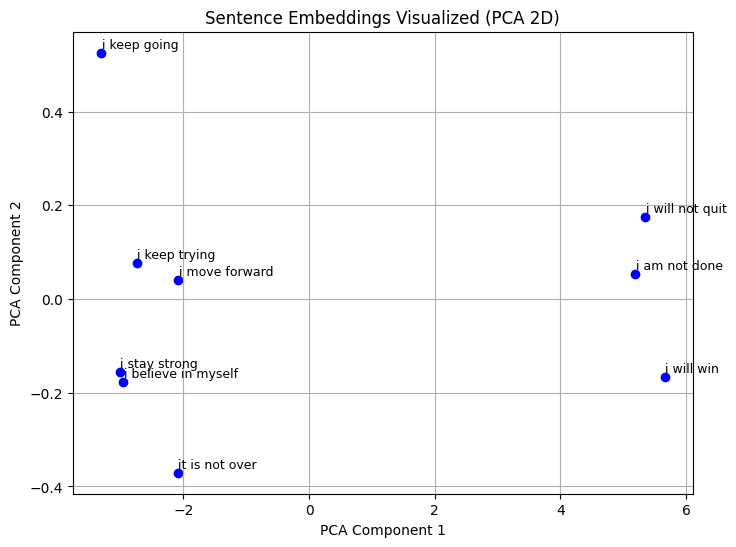

In [56]:
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Get embeddings for all sentences
sentence_vectors = []
for text in texts:
    tokens = torch.tensor(vocab.encode(text)).to(device)
    with torch.no_grad():
        vector = model(tokens).cpu().numpy()
    sentence_vectors.append(vector)


# Reduce to 2D for visualization
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(sentence_vectors)

# Plot
plt.figure(figsize=(8,6))
for i, text in enumerate(texts):
    x, y = vectors_2d[i]
    plt.scatter(x, y, color='blue')
    plt.text(x+0.01, y+0.01, text, fontsize=9)

plt.title("Sentence Embeddings Visualized (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()